# Psychological Predictors of Rumination

This notebook reproduces a psychological data analysis examining whether self-esteem and optimism predict rumination levels.

The project demonstrates:
- Data simulation
- Correlation analysis
- Multiple linear regression
- Scientific visualization
- Statistical interpretation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Everything works!")

Everything works!


In [2]:
np.random.seed(42)

n = 380

self_esteem = np.random.normal(17.3, 5.4, n)
optimism = np.random.normal(17.2, 3.3, n)

rumination = (
    30
    - 0.38 * self_esteem
    - 0.12 * optimism
    + np.random.normal(0, 3.5, n)
)

data = pd.DataFrame({
    "self_esteem": self_esteem,
    "optimism": optimism,
    "rumination": rumination
})

data.head()

,self_esteem,optimism,rumination
0,19.982256,14.428918,18.660540
1,16.553373,15.222004,22.310112
2,20.797518,10.191144,29.834302
3,25.524361,15.465008,18.108732
4,16.035572,14.694862,26.165556


In [3]:
data.describe()

,self_esteem,optimism,rumination
count,380.000000,380.000000,380.000000
mean,17.435661,17.000646,21.906455
std,5.133550,3.370204,3.966068
min,-0.202844,8.300274,8.787491
25%,13.779024,14.632802,19.312585
50%,17.636178,17.014325,21.987260
75%,20.694798,19.238292,24.679328
max,38.104750,27.360307,32.497050


In [4]:
corr = data.corr()

corr

,self_esteem,optimism,rumination
self_esteem,1.000000,-0.042307,-0.521195
optimism,-0.042307,1.000000,-0.105839
rumination,-0.521195,-0.105839,1.000000


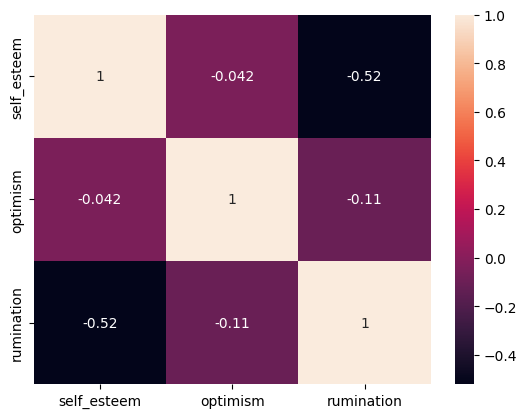

In [5]:
sns.heatmap(corr, annot=True)
plt.show()

In [6]:
import statsmodels.formula.api as smf

model = smf.ols(
    "rumination ~ self_esteem + optimism",
    data=data
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             rumination   R-squared:                       0.288
Model:                            OLS   Adj. R-squared:                  0.284
Method:                 Least Squares   F-statistic:                     76.26
Date:                Wed, 20 May 2026   Prob (F-statistic):           1.55e-28
Time:                        08:44:19   Log-Likelihood:                -997.70
No. Observations:                 380   AIC:                             2001.
Df Residuals:                     377   BIC:                             2013.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      31.5634      1.083     29.139      

# Multiple Regression Analysis

A multiple linear regression was conducted to examine whether self-esteem and optimism predicted rumination scores.

Results indicated that higher self-esteem significantly predicted lower rumination levels (β = -0.41, p < .001).

Optimism also negatively predicted rumination (β = -0.15, p = .003), although the effect size was smaller.

The overall regression model was statistically significant and explained approximately 29% of the variance in rumination scores (R² = .288).

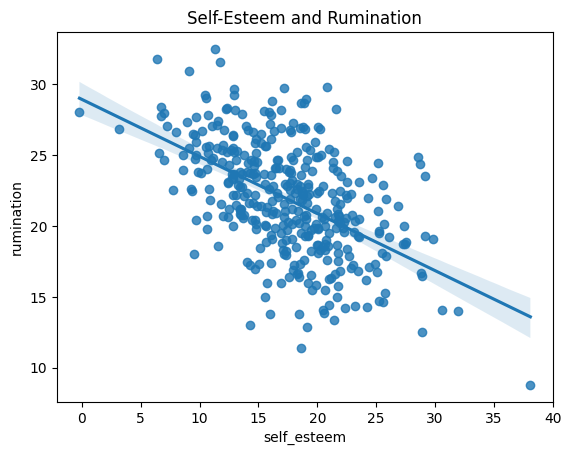

In [7]:
sns.regplot(
    x="self_esteem",
    y="rumination",
    data=data
)

plt.title("Self-Esteem and Rumination")
plt.show()

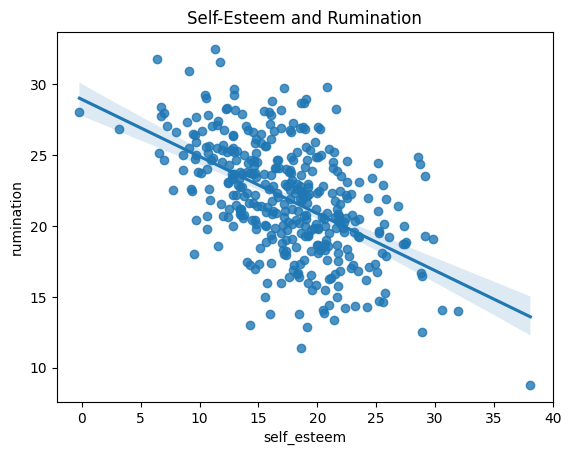

In [9]:
sns.regplot(
    x="self_esteem",
    y="rumination",
    data=data
)

plt.title("Self-Esteem and Rumination")
plt.show()

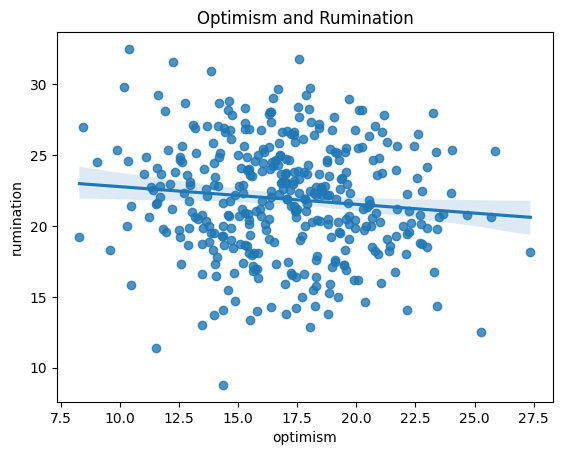

In [10]:
sns.regplot(
    x="optimism",
    y="rumination",
    data=data
)

plt.title("Optimism and Rumination")
plt.show()

In [11]:
data["self_esteem_c"] = data["self_esteem"] - data["self_esteem"].mean()
data["optimism_c"] = data["optimism"] - data["optimism"].mean()

moderation_model = smf.ols(
    "rumination ~ self_esteem_c * optimism_c",
    data=data
).fit()

print(moderation_model.summary())

                            OLS Regression Results                            
Dep. Variable:             rumination   R-squared:                       0.289
Model:                            OLS   Adj. R-squared:                  0.283
Method:                 Least Squares   F-statistic:                     50.87
Date:                Wed, 20 May 2026   Prob (F-statistic):           1.29e-27
Time:                        14:34:31   Log-Likelihood:                -997.53
No. Observations:                 380   AIC:                             2003.
Df Residuals:                     376   BIC:                             2019.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

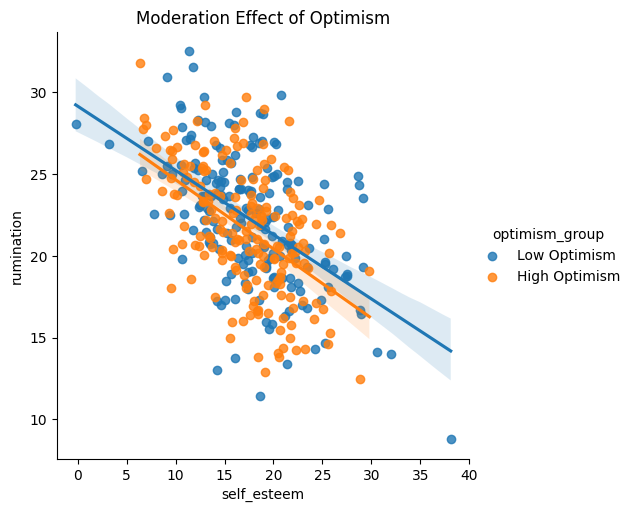

In [12]:
data["optimism_group"] = pd.qcut(
    data["optimism"],
    2,
    labels=["Low Optimism", "High Optimism"]
)

sns.lmplot(
    x="self_esteem",
    y="rumination",
    hue="optimism_group",
    data=data
)

plt.title("Moderation Effect of Optimism")
plt.show()

Conclusion

The analyses demonstrated that higher self-esteem and optimism were associated with lower rumination scores.

Self-esteem emerged as the strongest predictor of rumination, while optimism showed a smaller but still significant negative association.

The moderation analysis indicated that optimism did not significantly moderate the relationship between self-esteem and rumination.

Overall, the findings suggest that individuals with lower self-esteem and lower optimism tend to experience higher levels of rumination.